# 00 Data Exploration — NFHS-5 (Stage 1)

This notebook performs initial EDA for the district-level NFHS-5 dataset used in BarrierLens Stage 1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_PATH = PROJECT_ROOT / 'data' / 'raw' / 'NFHS5_Individual.csv'
print('Project root:', PROJECT_ROOT)
print('Raw path:', RAW_PATH)

Project root: C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48
Raw path: C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48\data\raw\NFHS5_Individual.csv


In [2]:
df = pd.read_csv(RAW_PATH)
df.columns = df.columns.str.strip()

print('Shape:', df.shape)
print('First 10 columns:')
print(df.columns[:10].tolist())
print('\nDtypes (top 20):')
print(df.dtypes.head(20))

df.head(3)

C:\Users\hireg\AppData\Local\Temp\ipykernel_29976\3571071701.py:1: DtypeWarning: Columns (0: s245a, 1: s245b, 2: s245h) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(RAW_PATH)


Shape: (724115, 32)
First 10 columns:
['caseid', 'v001', 'v002', 'v021', 'v024', 'v025', 'v012', 'v013', 'v106', 'v130']

Dtypes (top 20):
caseid      str
v001      int64
v002      int64
v021      int64
v024        str
v025        str
v012      int64
v013        str
v106        str
v130        str
v131        str
v501        str
v717        str
v190        str
v169a       str
v170        str
v481        str
v157        str
v158        str
v159        str
dtype: object


,caseid,v001,v002,v021,v024,v025,v012,v013,v106,v130,...,v467b,v467c,v467d,v467e,v467g,v467h,v626a,s245a,s245b,s245h
0,0100101305 04,113,5,113,jammu & kashmir,rural,22,20-24,higher,muslim,...,big problem,not a big problem,not a big problem,big problem,big problem,big problem,never had sex,NaN,NaN,NaN
1,0100101305 05,113,5,113,jammu & kashmir,rural,19,15-19,secondary,muslim,...,big problem,big problem,big problem,big problem,big problem,big problem,never had sex,NaN,NaN,NaN
2,0100101345 02,113,45,113,jammu & kashmir,rural,38,35-39,primary,muslim,...,no problem,no problem,no problem,no problem,no problem,no problem,using for limiting,NaN,NaN,NaN


In [3]:
missing_by_col = df.isnull().sum().sort_values(ascending=False)
missing_by_col = missing_by_col[missing_by_col > 0]

print('Columns with missing values:', missing_by_col.shape[0])
missing_by_col.head(20)

Columns with missing values: 9


v466     724115
s245b    723974
s245a    723974
s245h    723974
v743f    648289
v170     615330
v169a    615330
v717     615330
v626a       160
dtype: int64

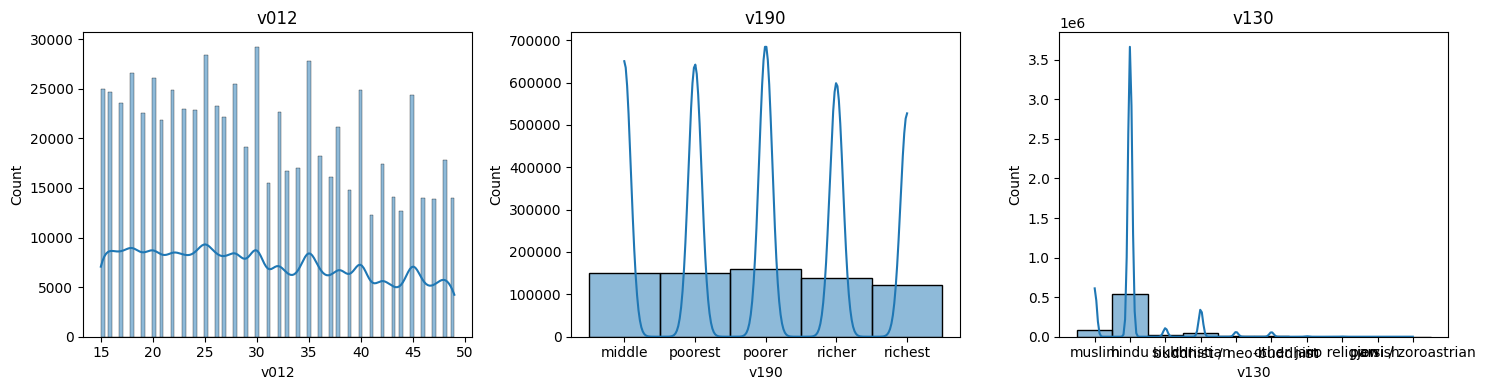

In [4]:
sample_cols = [
    'v012',
    'v190',
    'v130',
]

plot_cols = [c for c in sample_cols if c in df.columns]
num = len(plot_cols)

if num > 0:
    fig, axes = plt.subplots(1, num, figsize=(5 * num, 4))
    if num == 1:
        axes = [axes]

    for ax, col in zip(axes, plot_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=ax)
        ax.set_title(col)

    plt.tight_layout()
    plt.show()
else:
    print("No valid columns to plot.")


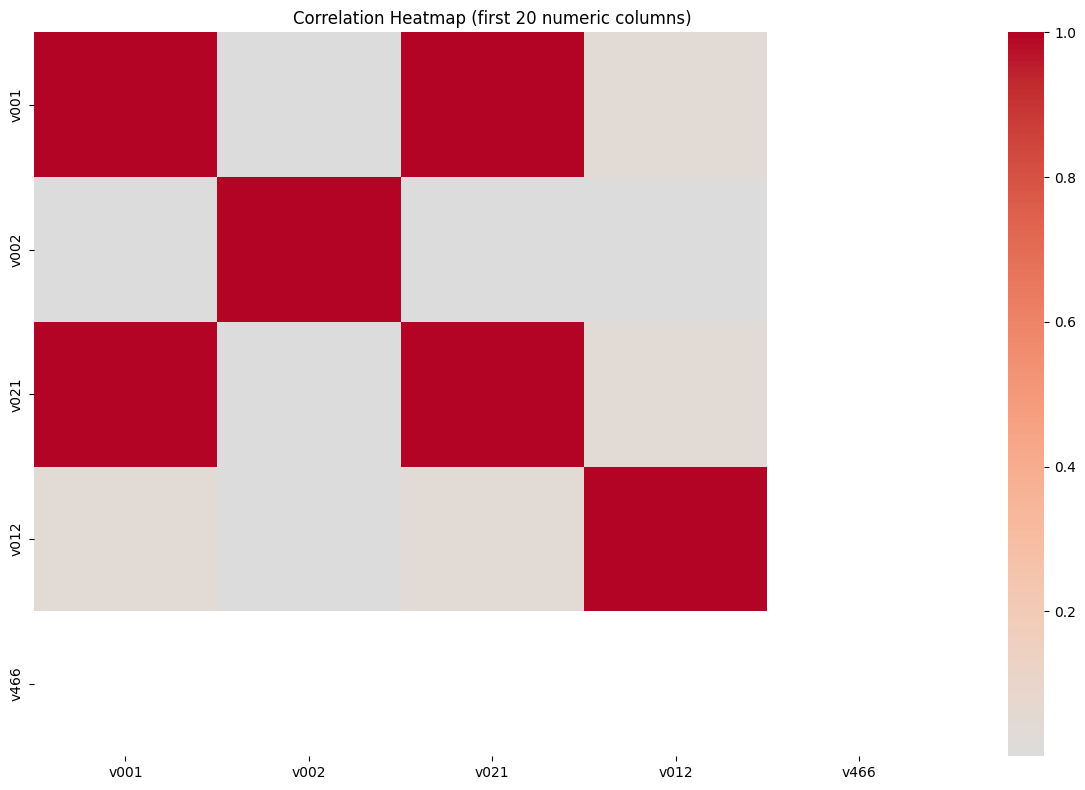

In [5]:
numeric_df = df.select_dtypes(include=[np.number]).copy()

# Keep the view readable by focusing on the first 20 numeric columns.
heatmap_cols = numeric_df.columns[:20]
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df[heatmap_cols].corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (first 20 numeric columns)')
plt.tight_layout()
plt.show()